# Pointing and Aligment Errors

In this notebook we detail the most important sources of error that affect the barycentric stellar positions from an perfect performing payload. Generally one can classify two main sources of error: those who are related to the pointing precision of the platform from mission quarter to the next, and those errors that are related to the physical integration and assembly of the payload which always will have small misalignments present. The latter is further enhanced when the spacecraft is launched to space and vibrations will introduce further misalignment and slight tilts of different camera components (like the lenses and CCDs). Below we show how to include a realistic distribution of the platform pointing and camera misalignment errors. 

### Setup notebook

In [1]:
# Alow changes to the PlatoSim code outside this notebook
%load_ext autoreload
%autoreload 2

# Configure figure in notebook
%matplotlib notebook

### Imports

In [2]:
# Second part libraries
import os
import sys
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.ndimage import median_filter
from astropy import units as u
from astropy.coordinates import SkyCoord

# PlatoSim libraries
import platosim.plot      as pt
import platosim.noise     as ns
import platosim.utilities as ut
from platosim.matplotlibrc import setup_notebook
setup_notebook()

---
## 1 - Platform pointing errors
---

The pointing of the PLATO platform from mission quarter to the next will be extremely precise, however, not perfect. This means that the Pointing Repeatability Error (PREs) will introduce small barycentric shifts of the stars every time the observations are interrupted (i.e. also after safe mode events, etc). 

Let's assume we want to generate a PRE file for the LOPS2 pointing. First we fetch this pointing with:

In [3]:
alpha, delta, kappa = ut.getPointingField('LOPS2')
alpha, delta, kappa

(95.31043, -47.88693, 193.9947)

We can now use the function `ns.getPRE()` to generate random pointing offset. Below we simulate 1000 realisations of the PRE just for illustrative purposes- and we use a requirement that the errors should be within a $3 \sigma$ compared to that of the mission requirement:


Change of coordinates [arcsec]
     quarter       yaw     pitch      roll
0          1  0.167580 -0.338374 -0.261442
1          2  3.024762 -0.537315 -0.604553
2          3 -0.674644 -0.496281 -0.320254
3          4  1.949841 -0.216295 -0.293635
4          5  0.858654 -0.393913 -0.349912
..       ...       ...       ...       ...
994      995  1.054514 -0.028760 -0.093643
995      996 -2.490900  0.063618  0.218009
996      997  1.602983  2.285923  1.578416
997      998  0.520670  1.079367  0.761515
998      999 -0.388090  0.064681  0.074421

[999 rows x 4 columns]

New ICRS coordinates [deg]
     quarter         RA        Dec     kappa
0          1  95.310477 -47.887024 -0.000073
1          2  95.311270 -47.887079 -0.000168
2          3  95.310243 -47.887068 -0.000089
3          4  95.310972 -47.886990 -0.000082
4          5  95.310669 -47.887039 -0.000097
..       ...        ...        ...       ...
994      995  95.310723 -47.886938 -0.000026
995      996  95.309738 -47.886912  0.00

<IPython.core.display.Javascript object>


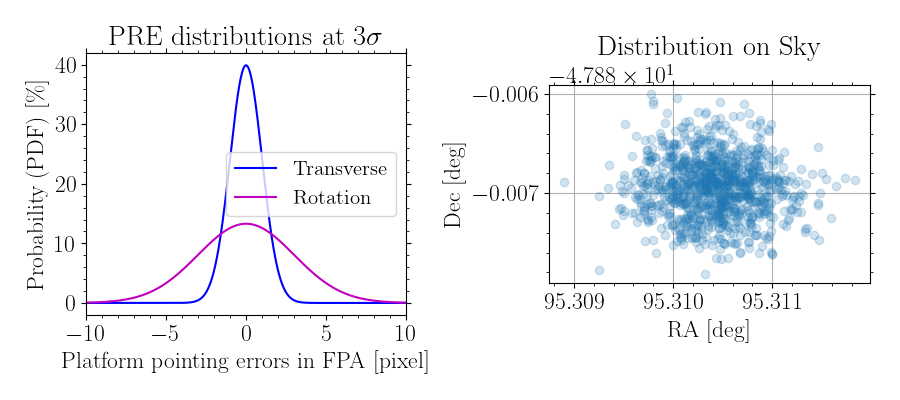

In [4]:
PRE = ns.getPRE(alpha, delta, kappa, range(1,1000), sigma=3, show_table=True, plot=True)

From the above figures its shown that the mission requirement of drawing the PRE from a $3 \sigma$ distribution results in small barycentric pixel displacement of the stars less than a few pixels.

### 2 - Camera misalignments


Camera alignment errors for all 24 N-CAMs [pixel]
          Alt        Az        Yaw      Pitch       Roll
0   -1.080437 -6.401575  -3.160266  -1.080437  -3.241310
1    3.888096  1.030434 -10.633853   3.888096  11.664287
2    2.199340  5.834608  -0.763412   2.199340   6.598020
3   -1.411872  2.777365   7.012980  -1.411872  -4.235615
4    4.440379  4.029190  -9.291946   4.440379  13.321136
5   11.315513 -9.658607 -43.605146  11.315513  33.946539
6    6.606473  9.220377 -10.599043   6.606473  19.819419
7    4.945044  3.963051 -10.872082   4.945044  14.835132
8    3.785162  5.249001  -6.106486   3.785162  11.355487
9   -3.341048  1.481367  11.504510  -3.341048 -10.023143
10  -2.468101  6.696485  14.100789  -2.468101  -7.404304
11  -3.352986  3.462410  13.521368  -3.352986 -10.058958
12   2.217677  1.217443  -5.435587   2.217677   6.653031
13  10.000463  1.915182 -28.086205  10.000463  30.001388
14  -2.743951 -7.979283   0.252570  -2.743951  -8.231853
15  -3.176558  3.928602  13.458276  -

<IPython.core.display.Javascript object>


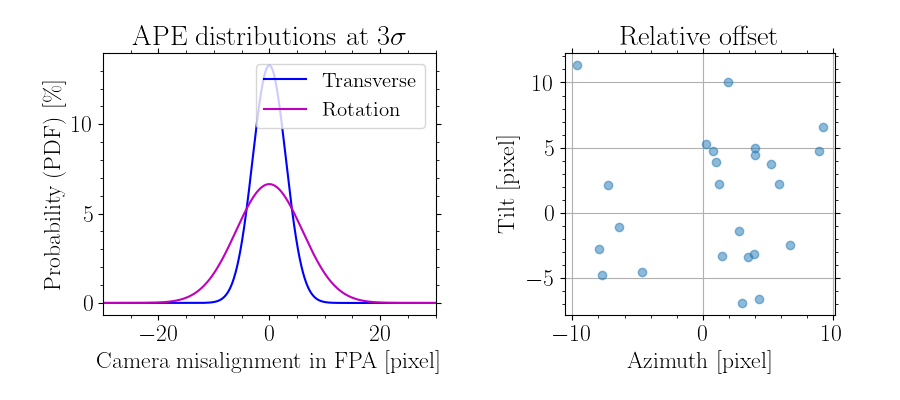

In [37]:
APE = ns.getAPE(alpha, delta, kappa, sigma=3, show_table=True, plot=True)